<a href="https://colab.research.google.com/github/Sajjad5/causal-portfolio-risk/blob/main/Causal_Attribution_Portfolio_Risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Causal Attribution of Portfolio Risk

From Correlated Factors to Interventions

This project analyzes which financial and macroeconomic risk factors cause changes in portfolio P&L and risk measures, and how these causal effects differ in normal vs stress regimes (including the Iran–USA conflict era).


**Objective**

The first step is to collect financial and macroeconomic variables that may influence portfolio performance.

**We need:**

**Market Variables**

* S&P 500 (US Equity Market)
* DAX (German Equity Market)
* VIX (Market Fear Index)
* EUR/USD Exchange Rate
* Macroeconomic Variables
* US Treasury Yields
* Inflation (CPI)
* Industrial Production
* Economic Sentiment Indicators

These variables will later be used for causal discovery and causal inference.

**Why?**

Traditional risk models assume correlation.

**For example:**

**VIX ↑ and Portfolio ↓**

But correlation alone cannot tell us whether VIX actually causes portfolio losses.

Therefore we collect potential causal drivers first.

In [61]:
# ============================================================
# 1. INSTALL REQUIRED PACKAGES
# ============================================================

!pip install yfinance fredapi causal-learn dowhy econml graphviz pydot networkx --quiet

In [62]:
# ============================================================
# 1.1 IMPORT LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import yfinance as yf

from fredapi import Fred

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

import networkx as nx

# 2. Define Research Parameters

Here we define the full research period and the stress window.

The stress window is based on the Iran–USA conflict period:

28 February 2026 to 31 March 2026

This period is used to compare normal market behavior with geopolitical stress behavior.

In [63]:
# ============================================================
# 2. RESEARCH TIME PERIOD
# ============================================================

START_DATE = "2018-01-01"
END_DATE = "2026-04-15"

# Iran-USA War / Conflict Stress Window
WAR_START = "2026-02-28"
WAR_END = "2026-03-31"

#3. Define Market Risk Factors

**Explanation**

We select financial variables that represent different portfolio risk channels.

* SP500	US equity risk
* DAX	German equity risk
* VIX	volatility / fear index
* EURUSD	currency risk
* GOLD	safe-haven asset
* OIL	energy / geopolitical risk
* US Treasury ETF	interest-rate exposure



In [64]:
# ============================================================
# 3. MARKET RISK FACTORS
# ============================================================

market_tickers = {
    "SP500": "^GSPC",
    "DAX": "^GDAXI",
    "VIX": "^VIX",
    "EURUSD": "EURUSD=X",
    "GOLD": "GC=F",
    "OIL": "CL=F",
    "US_TREASURY_ETF": "IEF"
}

# 4. Download Market Data

**Explanation**

We download adjusted closing prices from Yahoo Finance.

Adjusted prices are used because they are more suitable for return calculation.

In [65]:
# ============================================================
# 4. DOWNLOAD MARKET PRICES
# ============================================================

market_prices = pd.DataFrame()

for name, ticker in market_tickers.items():
    print(f"Downloading {name}: {ticker}")

    temp = yf.download(
        ticker,
        start=START_DATE,
        end=END_DATE,
        auto_adjust=True,
        progress=False
    )

    market_prices[name] = temp["Close"]

market_prices.head()

,SP500,DAX,VIX,EURUSD,GOLD,OIL,US_TREASURY_ETF
Date,,,,,,,
2018-01-02,2695.810059,12871.389648,9.77,1.201158,1313.699951,60.369999,86.110947
2018-01-03,2713.060059,12978.209961,9.15,1.206345,1316.199951,61.630001,86.200974
2018-01-04,2723.989990,13167.889648,9.22,1.201043,1319.400024,62.009998,86.160095
2018-01-05,2743.149902,13319.639648,9.22,1.206884,1320.300049,61.439999,86.053650
2018-01-08,2747.709961,13367.780273,9.52,1.203746,1318.599976,61.730000,86.012749


In [66]:
market_prices.head()

,SP500,DAX,VIX,EURUSD,GOLD,OIL,US_TREASURY_ETF
Date,,,,,,,
2018-01-02,2695.810059,12871.389648,9.77,1.201158,1313.699951,60.369999,86.110947
2018-01-03,2713.060059,12978.209961,9.15,1.206345,1316.199951,61.630001,86.200974
2018-01-04,2723.989990,13167.889648,9.22,1.201043,1319.400024,62.009998,86.160095
2018-01-05,2743.149902,13319.639648,9.22,1.206884,1320.300049,61.439999,86.053650
2018-01-08,2747.709961,13367.780273,9.52,1.203746,1318.599976,61.730000,86.012749


In [67]:
# ============================================================
# 4.1 CHECK MISSING VALUES
# ============================================================

print("Dataset shape:", market_prices.shape)
print(market_prices.isna().sum())

Dataset shape: (2081, 7)
SP500               0
DAX                37
VIX                 0
EURUSD              2
GOLD                1
OIL                 0
US_TREASURY_ETF     0
dtype: int64


# 5. Download Macroeconomic Data

**Explanation**

Market movements are often caused by macroeconomic forces.

We include interest rates, inflation, and industrial production to reduce omitted-variable bias.

In [68]:
# ============================================================
# 5. FRED API SETUP
# ============================================================

FRED_API_KEY = "fbf67578fdd8839127161f1709548ce7"

fred = Fred(api_key=FRED_API_KEY)

In [69]:
# ============================================================
# 5.1 FRED MACRO SERIES
# ============================================================

fred_series = {
    "US10Y": "DGS10",
    "US2Y": "DGS2",
    "FEDFUNDS": "FEDFUNDS",
    "CPI_US": "CPIAUCSL",
    "INDPRO_US": "INDPRO"
}

In [70]:
import time
# ============================================================
# 5.2 DOWNLOAD MACRO DATA
# ============================================================

macro_data = pd.DataFrame()

for name, code in fred_series.items():
    print(f"Downloading {name}: {code}")

    macro_data[name] = fred.get_series(
        code,
        observation_start=START_DATE,
        observation_end=END_DATE
    )
    time.sleep(1) # Add a delay to avoid rate limits

macro_data.head()

,US10Y,US2Y,FEDFUNDS,CPI_US,INDPRO_US
2018-01-01,NaN,NaN,1.41,248.859,101.4625
2018-01-02,2.46,1.92,NaN,NaN,NaN
2018-01-03,2.44,1.94,NaN,NaN,NaN
2018-01-04,2.46,1.96,NaN,NaN,NaN
2018-01-05,2.47,1.96,NaN,NaN,NaN


In [71]:
# ============================================================
# 5.3 HANDLE MISSING VALUES IN MACRO DATA
# ============================================================

print("Missing values before handling:")
print(macro_data.isnull().sum())

Missing values before handling:
US10Y          92
US2Y           92
FEDFUNDS     2092
CPI_US       2093
INDPRO_US    2092
dtype: int64


In [72]:
# Use forward fill to handle missing values
macro_data_filled = macro_data.ffill()

print("\nMissing values after forward fill:")
print(macro_data_filled.isnull().sum())

display(macro_data_filled.head())


Missing values after forward fill:
US10Y        1
US2Y         1
FEDFUNDS     0
CPI_US       0
INDPRO_US    0
dtype: int64


,US10Y,US2Y,FEDFUNDS,CPI_US,INDPRO_US
2018-01-01,NaN,NaN,1.41,248.859,101.4625
2018-01-02,2.46,1.92,1.41,248.859,101.4625
2018-01-03,2.44,1.94,1.41,248.859,101.4625
2018-01-04,2.46,1.96,1.41,248.859,101.4625
2018-01-05,2.47,1.96,1.41,248.859,101.4625


In [73]:
# Apply backward fill to handle any remaining initial NaN values
macro_data_filled = macro_data_filled.bfill()

print("\nMissing values after backward fill:")
print(macro_data_filled.isnull().sum())

display(macro_data_filled.head())


Missing values after backward fill:
US10Y        0
US2Y         0
FEDFUNDS     0
CPI_US       0
INDPRO_US    0
dtype: int64


,US10Y,US2Y,FEDFUNDS,CPI_US,INDPRO_US
2018-01-01,2.46,1.92,1.41,248.859,101.4625
2018-01-02,2.46,1.92,1.41,248.859,101.4625
2018-01-03,2.44,1.94,1.41,248.859,101.4625
2018-01-04,2.46,1.96,1.41,248.859,101.4625
2018-01-05,2.47,1.96,1.41,248.859,101.4625


#6. Feature Engineering

**Explanation**

We convert price levels into log returns.

Returns are better for risk modeling because prices are usually non-stationary.

For macro variables, we use changes and growth rates.

In [74]:
# ============================================================
# 6. MARKET LOG RETURNS
# ============================================================

market_returns = np.log(
    market_prices / market_prices.shift(1)
)

market_returns = market_returns.add_suffix("_RET")

market_returns.head()

,SP500_RET,DAX_RET,VIX_RET,EURUSD_RET,GOLD_RET,OIL_RET,US_TREASURY_ETF_RET
Date,,,,,,,
2018-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,0.006378,0.008265,-0.065563,0.004309,0.001901,0.020657,0.001045
2018-01-04,0.004021,0.014509,0.007621,-0.004406,0.002428,0.006147,-0.000474
2018-01-05,0.007009,0.011458,0.000000,0.004852,0.000682,-0.009235,-0.001236
2018-01-08,0.001661,0.003608,0.032020,-0.002603,-0.001288,0.004709,-0.000475


In [75]:
# ============================================================
# 6.1 MACRO FEATURES
# ============================================================

macro_features = pd.DataFrame(index=macro_data_filled.index)

macro_features["US10Y_CHANGE"] = macro_data_filled["US10Y"].diff()
macro_features["US2Y_CHANGE"] = macro_data_filled["US2Y"].diff()
macro_features["FEDFUNDS_CHANGE"] = macro_data_filled["FEDFUNDS"].diff()

macro_features["TERM_SPREAD"] = macro_data_filled["US10Y"] - macro_data_filled["US2Y"]

macro_features["CPI_US_GROWTH"] = np.log(
    macro_data_filled["CPI_US"] / macro_data_filled["CPI_US"].shift(1)
)

macro_features["INDPRO_US_GROWTH"] = np.log(
    macro_data_filled["INDPRO_US"] / macro_data_filled["INDPRO_US"].shift(1)
)

macro_features.head()

,US10Y_CHANGE,US2Y_CHANGE,FEDFUNDS_CHANGE,TERM_SPREAD,CPI_US_GROWTH,INDPRO_US_GROWTH
2018-01-01,NaN,NaN,NaN,0.54,NaN,NaN
2018-01-02,0.00,0.00,0.0,0.54,0.0,0.0
2018-01-03,-0.02,0.02,0.0,0.50,0.0,0.0
2018-01-04,0.02,0.02,0.0,0.50,0.0,0.0
2018-01-05,0.01,0.00,0.0,0.51,0.0,0.0


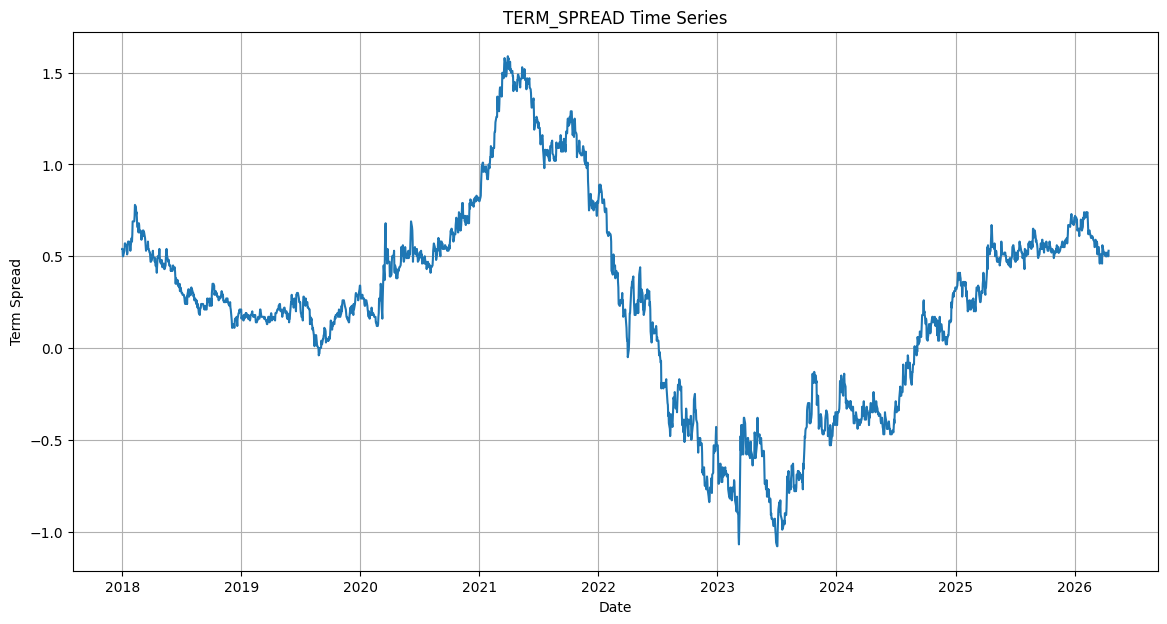

In [76]:
# ============================================================
# 6.2 PLOT TERM_SPREAD TIME SERIES
# ============================================================

plt.figure(figsize=(14, 7))
plt.plot(macro_features.index, macro_features['TERM_SPREAD'])
plt.title('TERM_SPREAD Time Series')
plt.xlabel('Date')
plt.ylabel('Term Spread')
plt.grid(True)
plt.show()

#7. Merge Dataset

**Explanation**

Yahoo data is daily. FRED macro data can be daily, monthly, or lower frequency.

Therefore:

we merge by date,
forward-fill macro data,
remove missing values.

In [77]:
# ============================================================
# 7. MERGE MARKET AND MACRO DATA
# ============================================================

full_data = pd.concat(
    [market_returns, macro_features],
    axis=1
)

full_data = full_data.sort_index()
full_data = full_data.ffill().bfill() # Apply both ffill and bfill to handle all NaNs
full_data = full_data.dropna()

full_data.head()

,SP500_RET,DAX_RET,VIX_RET,EURUSD_RET,GOLD_RET,OIL_RET,US_TREASURY_ETF_RET,US10Y_CHANGE,US2Y_CHANGE,FEDFUNDS_CHANGE,TERM_SPREAD,CPI_US_GROWTH,INDPRO_US_GROWTH
2018-01-01,0.006378,0.008265,-0.065563,0.004309,0.001901,0.020657,0.001045,0.00,0.00,0.0,0.54,0.0,0.0
2018-01-02,0.006378,0.008265,-0.065563,0.004309,0.001901,0.020657,0.001045,0.00,0.00,0.0,0.54,0.0,0.0
2018-01-03,0.006378,0.008265,-0.065563,0.004309,0.001901,0.020657,0.001045,-0.02,0.02,0.0,0.50,0.0,0.0
2018-01-04,0.004021,0.014509,0.007621,-0.004406,0.002428,0.006147,-0.000474,0.02,0.02,0.0,0.50,0.0,0.0
2018-01-05,0.007009,0.011458,0.000000,0.004852,0.000682,-0.009235,-0.001236,0.01,0.00,0.0,0.51,0.0,0.0


#8. Portfolio Construction

Explanation

We now create the portfolio return.

This is the main outcome variable.

Example portfolio:

  Asset>>Weight
* SP500	 40%
* DAX	   25%
* US Treasury ETF	20%
* EUR/USD	10%
* Gold	5%

In [78]:
# ============================================================
# 8. PORTFOLIO WEIGHTS
# ============================================================

portfolio_weights = {
    "SP500_RET": 0.40,
    "DAX_RET": 0.25,
    "US_TREASURY_ETF_RET": 0.20,
    "EURUSD_RET": 0.10,
    "GOLD_RET": 0.05
}

In [79]:
# ============================================================
# 8.1 CALCULATE PORTFOLIO RETURNS
# ============================================================

full_data["PORTFOLIO_RET"] = 0

for asset, weight in portfolio_weights.items():
    full_data["PORTFOLIO_RET"] += weight * full_data[asset]

full_data[["PORTFOLIO_RET"]].head()

,PORTFOLIO_RET
2018-01-01,0.005353
2018-01-02,0.005353
2018-01-03,0.005353
2018-01-04,0.004822
2018-01-05,0.005940


#9. Create War Regime Indicator

**Explanation**

This variable separates normal observations from the Iran–USA war stress period.

0 = normal regime
1 = Iran–USA war stress regime

In [80]:
# ============================================================
# 9. IRAN-USA WAR REGIME INDICATOR
# ============================================================

full_data["IRAN_USA_WAR_REGIME"] = 0

full_data.loc[
    WAR_START:WAR_END,
    "IRAN_USA_WAR_REGIME"
] = 1

full_data["IRAN_USA_WAR_REGIME"].value_counts()

,count
IRAN_USA_WAR_REGIME,
0,2141
1,22


In [81]:
# ============================================================
# 9.1 SPLIT NORMAL AND WAR DATA
# ============================================================

war_data = full_data.loc[WAR_START:WAR_END]

normal_data = full_data[
    full_data["IRAN_USA_WAR_REGIME"] == 0
]

print("Full sample observations:", len(full_data))
print("Normal observations:", len(normal_data))
print("War observations:", len(war_data))

Full sample observations: 2163
Normal observations: 2141
War observations: 22


#10. Standardize Data

**Explanation**

Causal discovery algorithms work better when variables are on the same scale.

Standardization transforms each variable to:

mean = 0
standard deviation = 1

In [82]:
# ============================================================
# 10. STANDARDIZATION
# ============================================================

features_for_model = full_data.drop(
    columns=["IRAN_USA_WAR_REGIME"]
)

scaler = StandardScaler()

scaled_array = scaler.fit_transform(features_for_model)

scaled_data = pd.DataFrame(
    scaled_array,
    columns=features_for_model.columns,
    index=features_for_model.index
)

scaled_data["IRAN_USA_WAR_REGIME"] = full_data["IRAN_USA_WAR_REGIME"]

scaled_data.head()

,SP500_RET,DAX_RET,VIX_RET,EURUSD_RET,GOLD_RET,OIL_RET,US_TREASURY_ETF_RET,US10Y_CHANGE,US2Y_CHANGE,FEDFUNDS_CHANGE,TERM_SPREAD,CPI_US_GROWTH,INDPRO_US_GROWTH,PORTFOLIO_RET,IRAN_USA_WAR_REGIME
2018-01-01,0.482823,0.652767,-0.799935,0.934045,0.111149,0.670830,0.226797,-0.015485,-0.015115,-0.01841,0.531771,-0.122327,-0.001072,0.711722,0
2018-01-02,0.482823,0.652767,-0.799935,0.934045,0.111149,0.670830,0.226797,-0.015485,-0.015115,-0.01841,0.531771,-0.122327,-0.001072,0.711722,0
2018-01-03,0.482823,0.652767,-0.799935,0.934045,0.111149,0.670830,0.226797,-0.381550,0.340254,-0.01841,0.458542,-0.122327,-0.001072,0.711722,0
2018-01-04,0.288781,1.170737,0.101123,-0.962578,0.160123,0.189408,-0.122927,0.350579,0.340254,-0.01841,0.458542,-0.122327,-0.001072,0.636144,0
2018-01-05,0.534727,0.917659,0.007289,1.052094,-0.002131,-0.320938,-0.298303,0.167547,-0.015115,-0.01841,0.476849,-0.122327,-0.001072,0.795376,0


## 11. Basic Portfolio Risk Metrics

**Explanation**

Before causal analysis, we calculate traditional risk metrics:

* volatility,
* VaR,
* expected shortfall,
* skewness,
* kurtosis.

This gives us a baseline risk view.

In [83]:
# ============================================================
# 11. RISK METRICS FUNCTION
# ============================================================

def calculate_risk_metrics(returns, alpha=0.05):
    var = np.percentile(returns, alpha * 100)
    expected_shortfall = returns[returns <= var].mean()

    return {
        "Mean": returns.mean(),
        "Volatility": returns.std(),
        "Skewness": returns.skew(),
        "Kurtosis": returns.kurtosis(),
        "VaR_95": var,
        "Expected_Shortfall_95": expected_shortfall
    }

In [84]:
# ============================================================
# 11.1 COMPARE NORMAL VS WAR RISK
# ============================================================

normal_metrics = calculate_risk_metrics(
    normal_data["PORTFOLIO_RET"]
)

war_metrics = calculate_risk_metrics(
    war_data["PORTFOLIO_RET"]
)

risk_comparison = pd.DataFrame({
    "Normal_Regime": normal_metrics,
    "Iran_USA_War_Regime": war_metrics
})

risk_comparison

,Normal_Regime,Iran_USA_War_Regime
Mean,0.000385,-0.002802
Volatility,0.007007,0.008378
Skewness,-0.887368,0.296581
Kurtosis,15.756121,-1.006728
VaR_95,-0.010178,-0.014708
Expected_Shortfall_95,-0.016706,-0.014966


#12. Visualize Portfolio Returns

**Explanation**

This chart shows whether the war period had larger losses or higher volatility.

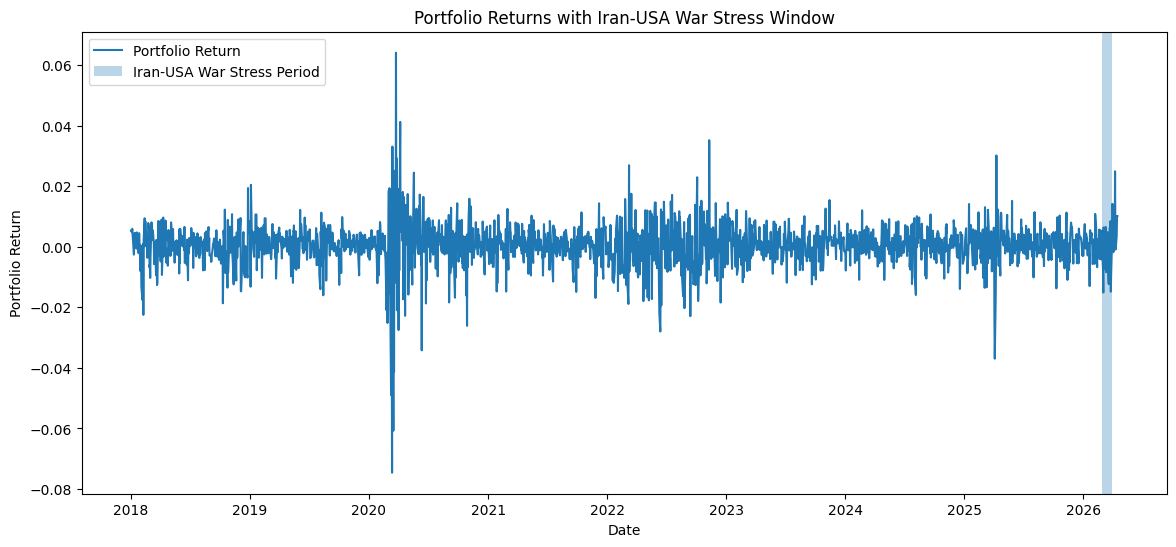

In [85]:
# ============================================================
# 12. PORTFOLIO RETURN VISUALIZATION
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    full_data.index,
    full_data["PORTFOLIO_RET"],
    label="Portfolio Return"
)

plt.axvspan(
    pd.to_datetime(WAR_START),
    pd.to_datetime(WAR_END),
    alpha=0.3,
    label="Iran-USA War Stress Period"
)

plt.title("Portfolio Returns with Iran-USA War Stress Window")
plt.xlabel("Date")
plt.ylabel("Portfolio Return")
plt.legend()
plt.show()

#13. Causal Discovery Using PC Algorithm

The PC Algorithm discovers possible causal relationships between variables using conditional independence tests.

It helps us move from simple correlation to a possible causal graph.

For example, instead of only saying:

**VIX is correlated with portfolio returns**

we test whether the data suggests:

**VIX → PORTFOLIO_RET**


In [86]:
# ============================================================
# 13. CAUSAL DISCOVERY USING PC ALGORITHM
# ============================================================

from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import fisherz

In [87]:
causal_variables = [
    "SP500_RET",
    "DAX_RET",
    "VIX_RET",
    "EURUSD_RET",
    "GOLD_RET",
    "OIL_RET",
    "US_TREASURY_ETF_RET",
    "US10Y_CHANGE",
    "PORTFOLIO_RET"
]

causal_dataset = scaled_data[causal_variables].dropna()

causal_dataset.head()

,SP500_RET,DAX_RET,VIX_RET,EURUSD_RET,GOLD_RET,OIL_RET,US_TREASURY_ETF_RET,US10Y_CHANGE,PORTFOLIO_RET
2018-01-01,0.482823,0.652767,-0.799935,0.934045,0.111149,0.670830,0.226797,-0.015485,0.711722
2018-01-02,0.482823,0.652767,-0.799935,0.934045,0.111149,0.670830,0.226797,-0.015485,0.711722
2018-01-03,0.482823,0.652767,-0.799935,0.934045,0.111149,0.670830,0.226797,-0.381550,0.711722
2018-01-04,0.288781,1.170737,0.101123,-0.962578,0.160123,0.189408,-0.122927,0.350579,0.636144
2018-01-05,0.534727,0.917659,0.007289,1.052094,-0.002131,-0.320938,-0.298303,0.167547,0.795376


In [88]:
# Run PC Algorithm

pc_result = pc(
    causal_dataset.values,
    alpha=0.05,
    indep_test="fisherz",
    stable=True
)

print(pc_result.G)

  0%|          | 0/9 [00:00<?, ?it/s]

Graph Nodes:
X1;X2;X3;X4;X5;X6;X7;X8;X9

Graph Edges:
1. X1 --> X2
2. X1 --- X3
3. X1 --> X6
4. X1 --> X9
5. X8 --> X2
6. X9 --> X2
7. X4 --> X9
8. X6 --> X5
9. X7 --> X5
10. X9 --> X5
11. X7 --> X6
12. X8 --> X6
13. X7 --- X8



#14. Causal Graph Visualization

The PC algorithm produces a graph structure.
This graph helps us visually inspect which variables are directly or indirectly linked to portfolio returns.

In [89]:
# ============================================================
# 14. VISUALIZE CAUSAL GRAPH
# ============================================================

from causallearn.utils.GraphUtils import GraphUtils
from IPython.display import Image, display

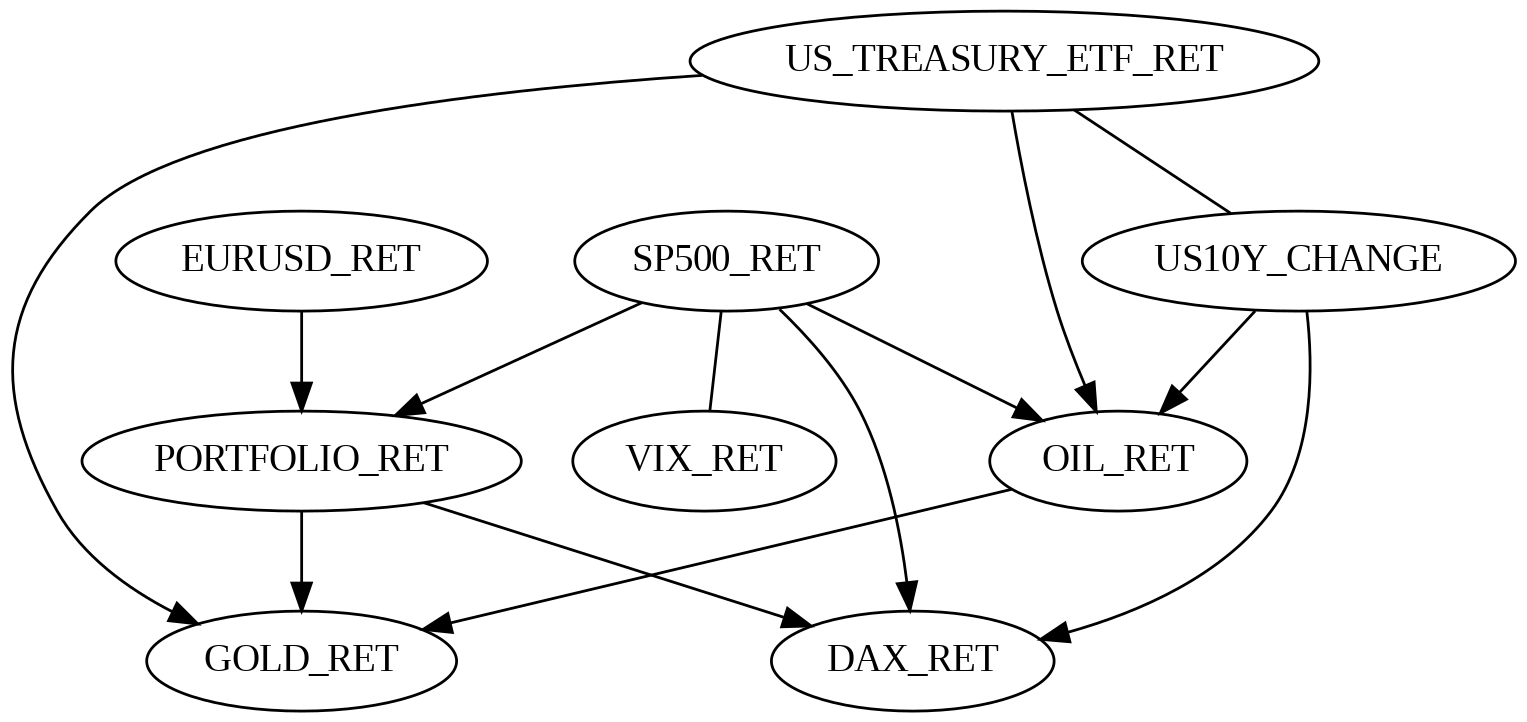

In [90]:
# Convert PC graph to PNG

pydot_graph = GraphUtils.to_pydot(
    pc_result.G,
    labels=causal_variables
)

pydot_graph.write_png("causal_graph_pc.png")

display(Image("causal_graph_pc.png"))

#15. DoWhy Causal Effect Estimation

Causal discovery tells us which links may exist.

DoWhy estimates the size of a causal effect.

Here we estimate:

Effect of VIX shock on portfolio return

Treatment:

**VIX_RET**

Outcome:

**PORTFOLIO_RET**

Common causes are control variables that may influence both treatment and outcome.

In [91]:
# ============================================================
# 15. CAUSAL EFFECT ESTIMATION USING DOWHY
# ============================================================

from dowhy import CausalModel

In [92]:
# Prepare DoWhy dataset

dowhy_data = scaled_data[
    [
        "PORTFOLIO_RET",
        "VIX_RET",
        "SP500_RET",
        "DAX_RET",
        "EURUSD_RET",
        "GOLD_RET",
        "OIL_RET",
        "US_TREASURY_ETF_RET",
        "US10Y_CHANGE"
    ]
].dropna()

In [93]:
# Identify causal estimand

import networkx as nx

# Get the causallearn graph's adjacency matrix
cl_adj_matrix = pc_result.G.graph

# Get the variable names directly from dowhy_data's columns for consistency
# This ensures that the graph nodes match the dataset columns
graph_node_names = dowhy_data.columns.tolist()

# Create an empty NetworkX DiGraph
G_dowhy = nx.DiGraph()

# Add nodes with actual variable names from graph_node_names
for var_name in graph_node_names:
    G_dowhy.add_node(var_name)

# Add edges based on the adjacency matrix from causallearn
num_nodes = len(graph_node_names) # Use the length of the consistent list
for i in range(num_nodes):
    for j in range(num_nodes):
        if cl_adj_matrix[i, j] == 1: # i -> j
            G_dowhy.add_edge(graph_node_names[i], graph_node_names[j])
        elif cl_adj_matrix[i, j] == 2: # i <- j (so j -> i)
            G_dowhy.add_edge(graph_node_names[j], graph_node_names[i])
        elif cl_adj_matrix[i, j] == 3: # i -- j (undirected)
            # For an undirected edge, represent as bidirected in a DiGraph for DoWhy
            G_dowhy.add_edge(graph_node_names[i], graph_node_names[j])
            G_dowhy.add_edge(graph_node_names[j], graph_node_names[i])

model_vix = CausalModel(
    data=dowhy_data,
    graph=G_dowhy, # Pass the networkx DiGraph object directly
    treatment="VIX_RET",
    outcome="PORTFOLIO_RET"
)

identified_estimand_vix = model_vix.identify_effect()

print(identified_estimand_vix)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                       
──────────(E[PORTFOLIO_RET])
d[VIX_RET]                  
Estimand assumption 1, Unconfoundedness: If U→{VIX_RET} and U→PORTFOLIO_RET then P(PORTFOLIO_RET|VIX_RET,,U) = P(PORTFOLIO_RET|VIX_RET,)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
    d                       
──────────(E[PORTFOLIO_RET])
d[VIX_RET]                  
Estimand assumption 1, Unconfoundedness: If U→{VIX_RET} and U→PORTFOLIO_RET then P(PORTFOLIO_RET|VIX_RET,,U) = P(PORTFOLIO_RET|VIX_RET,)



In [94]:
# Estimate causal effect

estimate_vix = model_vix.estimate_effect(
    identified_estimand_vix,
    method_name="backdoor.linear_regression"
)

print(estimate_vix)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                       
──────────(E[PORTFOLIO_RET])
d[VIX_RET]                  
Estimand assumption 1, Unconfoundedness: If U→{VIX_RET} and U→PORTFOLIO_RET then P(PORTFOLIO_RET|VIX_RET,,U) = P(PORTFOLIO_RET|VIX_RET,)

## Realized estimand
b: PORTFOLIO_RET~VIX_RET+VIX_RET*GOLD_RET+VIX_RET*EURUSD_RET
Target units: 

## Estimate
Mean value: -0.6707314499489101
### Conditional Estimates
__categorical__GOLD_RET  __categorical__EURUSD_RET
(-11.276, -0.584]        (-6.13, -0.73]              -0.763696
                         (-0.73, -0.22]              -0.764294
                         (-0.22, 0.201]              -0.755546
                         (0.201, 0.761]              -0.762920
                         (0.761, 5.989]              -0.778939
(-0.584, -0.148]         (-6.13, -0.73]              -0.680407
                     

In [95]:
# Refutation test

refutation_vix = model_vix.refute_estimate(
    identified_estimand_vix,
    estimate_vix,
    method_name="random_common_cause"
)

print(refutation_vix)

Refute: Add a random common cause
Estimated effect:-0.6707314499489101
New effect:-0.6707707810375372
p value:0.92



#16. EconML Treatment Effect Estimation

DoWhy gives a causal estimate using a classical method.

EconML allows machine-learning-based causal estimation.

Here we use Double Machine Learning.

This helps estimate the causal impact of VIX while controlling for nonlinear relationships in other market variables.

In [96]:
# ============================================================
# 16. ECONML DOUBLE MACHINE LEARNING
# ============================================================

from econml.dml import LinearDML
from sklearn.ensemble import RandomForestRegressor

In [97]:
Y = dowhy_data["PORTFOLIO_RET"]

T = dowhy_data["VIX_RET"]

X = dowhy_data[
    [
        "SP500_RET",
        "DAX_RET",
        "EURUSD_RET",
        "GOLD_RET",
        "OIL_RET",
        "US_TREASURY_ETF_RET",
        "US10Y_CHANGE"
    ]
]

In [98]:
# Fit LinearDML model

dml_model = LinearDML(
    model_y=RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),
    model_t=RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),
    random_state=42
)

dml_model.fit(Y, T, X=X)

In [99]:
# Estimate treatment effects

vix_effects = dml_model.effect(X)

print("Average treatment effect:", np.mean(vix_effects))
print("Minimum treatment effect:", np.min(vix_effects))
print("Maximum treatment effect:", np.max(vix_effects))

Average treatment effect: 0.03544277478062538
Minimum treatment effect: -0.9760957170778282
Maximum treatment effect: 0.8414078920277166


In [100]:
# Store treatment effects

dowhy_data["VIX_CAUSAL_EFFECT_DML"] = vix_effects

dowhy_data[["PORTFOLIO_RET", "VIX_RET", "VIX_CAUSAL_EFFECT_DML"]].head()

,PORTFOLIO_RET,VIX_RET,VIX_CAUSAL_EFFECT_DML
2018-01-01,0.711722,-0.799935,0.005972
2018-01-02,0.711722,-0.799935,0.005972
2018-01-03,0.711722,-0.799935,0.081108
2018-01-04,0.636144,0.101123,0.068942
2018-01-05,0.795376,0.007289,0.140635


#17. Interventional Risk Attribution

Now we simulate a causal intervention.

Instead of asking:

What happened when VIX moved?

we ask:

What would happen if VIX increased by 1 standard deviation?

This is the causal intervention:

**do(VIX_RET = VIX_RET + 1)**

In [101]:
# ============================================================
# 17. INTERVENTIONAL RISK ATTRIBUTION
# ============================================================

shock_size = 1.0

vix_causal_effect = estimate_vix.value

portfolio_impact_vix = shock_size * vix_causal_effect

print("Causal effect of 1 standard deviation VIX shock:")
print(portfolio_impact_vix)

Causal effect of 1 standard deviation VIX shock:
-0.6707314499489101


In [102]:
# Create intervention scenario

intervention_results = pd.DataFrame({
    "Factor": ["VIX_RET"],
    "Shock_Size": [shock_size],
    "Estimated_Causal_Effect": [vix_causal_effect],
    "Portfolio_Impact": [portfolio_impact_vix]
})

intervention_results

,Factor,Shock_Size,Estimated_Causal_Effect,Portfolio_Impact
0,VIX_RET,1.0,-0.670731,-0.670731


#17.1 Multi-Factor Causal Attribution

We repeat the DoWhy estimation for multiple factors.

This tells us which factor contributes most to portfolio risk under intervention.



In [103]:
# ============================================================
# 17.1 MULTI-FACTOR CAUSAL ATTRIBUTION
# ============================================================

risk_factors = [
    "VIX_RET",
    "OIL_RET",
    "GOLD_RET",
    "EURUSD_RET",
    "US10Y_CHANGE", # Ensure this is US10Y_CHANGE
    "DAX_RET",
    "SP500_RET"
]

outcome = "PORTFOLIO_RET"

causal_effects = []

In [104]:
for treatment in risk_factors:

    controls = [
        col for col in risk_factors
        if col != treatment
    ]

    temp_data = scaled_data[
        [outcome, treatment] + controls
    ].dropna()

    temp_model = CausalModel(
        data=temp_data,
        treatment=treatment,
        outcome=outcome,
        common_causes=controls
    )

    temp_estimand = temp_model.identify_effect()

    temp_estimate = temp_model.estimate_effect(
        temp_estimand,
        method_name="backdoor.linear_regression"
    )

    causal_effects.append({
        "Factor": treatment,
        "Causal_Effect": temp_estimate.value,
        "Abs_Effect": abs(temp_estimate.value)
    })

causal_attribution = pd.DataFrame(causal_effects)

causal_attribution = causal_attribution.sort_values(
    by="Abs_Effect",
    ascending=False
)

causal_attribution

,Factor,Causal_Effect,Abs_Effect
6,SP500_RET,0.688940,0.688940
5,DAX_RET,0.430938,0.430938
4,US10Y_CHANGE,-0.117638,0.117638
2,GOLD_RET,0.078477,0.078477
3,EURUSD_RET,0.064247,0.064247
1,OIL_RET,0.002072,0.002072
0,VIX_RET,-0.000648,0.000648


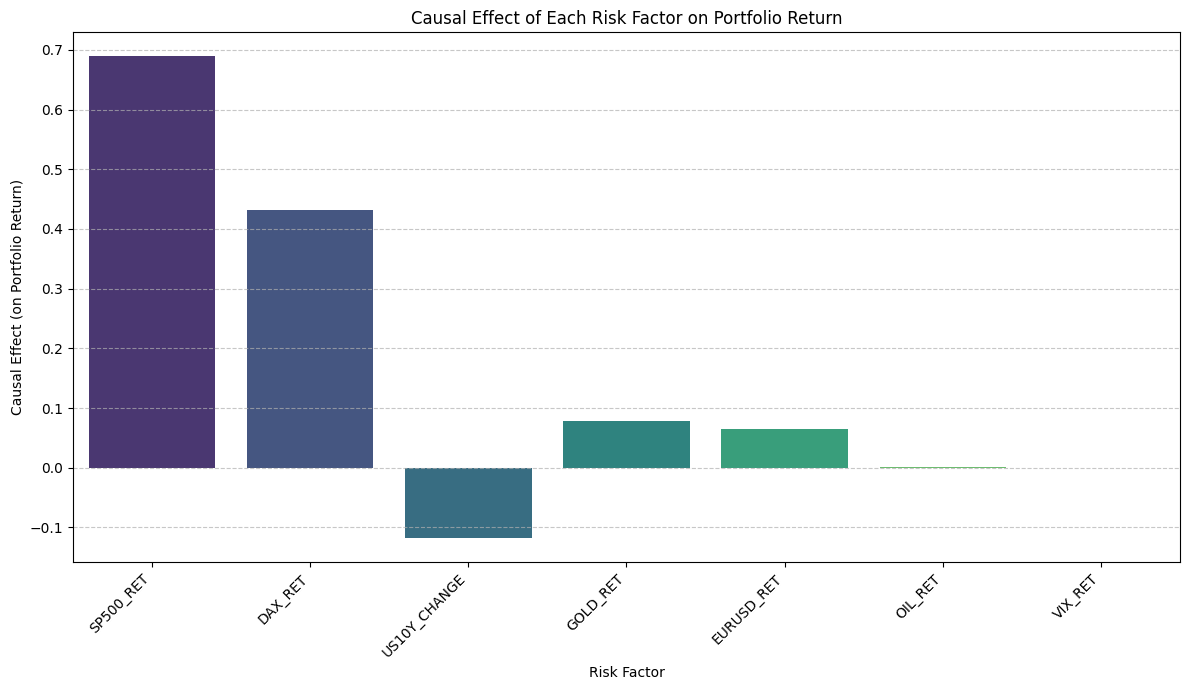

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='Factor', y='Causal_Effect', data=causal_attribution, palette='viridis')
plt.title('Causal Effect of Each Risk Factor on Portfolio Return')
plt.xlabel('Risk Factor')
plt.ylabel('Causal Effect (on Portfolio Return)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

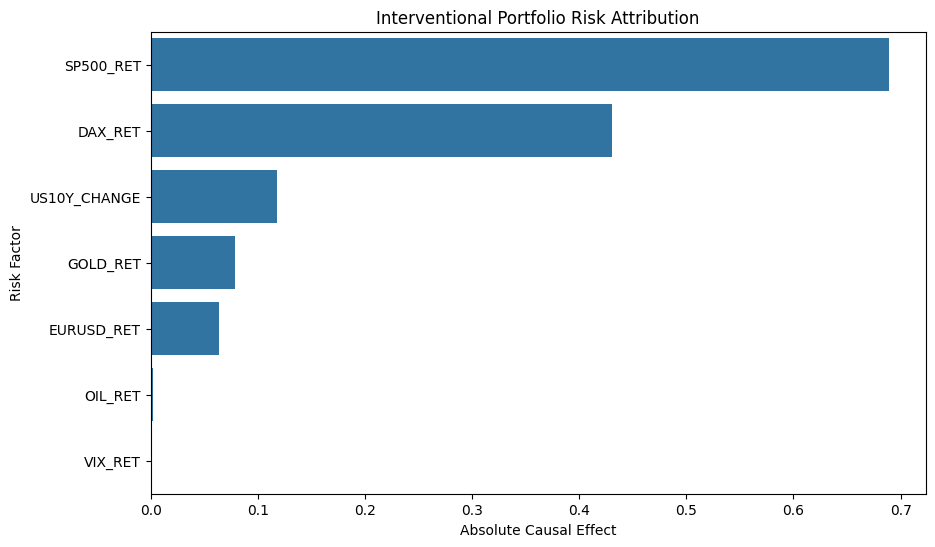

In [106]:
# Plot causal attribution

plt.figure(figsize=(10, 6))

sns.barplot(
    data=causal_attribution,
    x="Abs_Effect",
    y="Factor"
)

plt.title("Interventional Portfolio Risk Attribution")
plt.xlabel("Absolute Causal Effect")
plt.ylabel("Risk Factor")
plt.show()

#18. Normal vs War Regime Causal Comparison

Now we compare causal effects in:

Normal market regime

versus:

**Iran–USA war stress regime**

This is important because risk transmission usually changes during geopolitical stress.

A factor may have weak causal impact in normal markets but strong causal impact during war stress.

In [107]:
# ============================================================
# 18. NORMAL VS WAR REGIME CAUSAL COMPARISON
# ============================================================

def estimate_causal_effect_by_regime(data, treatment, outcome, controls):
    """
    Estimate causal effect using DoWhy for a given regime dataset.
    """

    model = CausalModel(
        data=data[[outcome, treatment] + controls].dropna(),
        treatment=treatment,
        outcome=outcome,
        common_causes=controls
    )

    estimand = model.identify_effect()

    estimate = model.estimate_effect(
        estimand,
        method_name="backdoor.linear_regression"
    )

    return estimate.value

In [108]:
# Split scaled data into normal and war regimes

scaled_war_data = scaled_data[
    scaled_data["IRAN_USA_WAR_REGIME"] == 1
]

scaled_normal_data = scaled_data[
    scaled_data["IRAN_USA_WAR_REGIME"] == 0
]

In [109]:
# Compare causal effects across regimes

regime_results = []

for treatment in risk_factors:

    controls = [
        factor for factor in risk_factors
        if factor != treatment
    ]

    try:
        normal_effect = estimate_causal_effect_by_regime(
            scaled_normal_data,
            treatment,
            outcome,
            controls
        )
    except:
        normal_effect = np.nan

    try:
        war_effect = estimate_causal_effect_by_regime(
            scaled_war_data,
            treatment,
            outcome,
            controls
        )
    except:
        war_effect = np.nan

    regime_results.append({
        "Factor": treatment,
        "Normal_Effect": normal_effect,
        "War_Effect": war_effect,
        "Effect_Difference": war_effect - normal_effect
    })

regime_comparison = pd.DataFrame(regime_results)

regime_comparison

,Factor,Normal_Effect,War_Effect,Effect_Difference
0,VIX_RET,-0.000727,-0.004111,-0.003384
1,OIL_RET,0.001944,0.002157,0.000213
2,GOLD_RET,0.078412,0.081259,0.002847
3,EURUSD_RET,0.064230,0.061866,-0.002363
4,US10Y_CHANGE,-0.117699,-0.118235,-0.000537
5,DAX_RET,0.430935,0.429681,-0.001254
6,SP500_RET,0.689009,0.673006,-0.016003


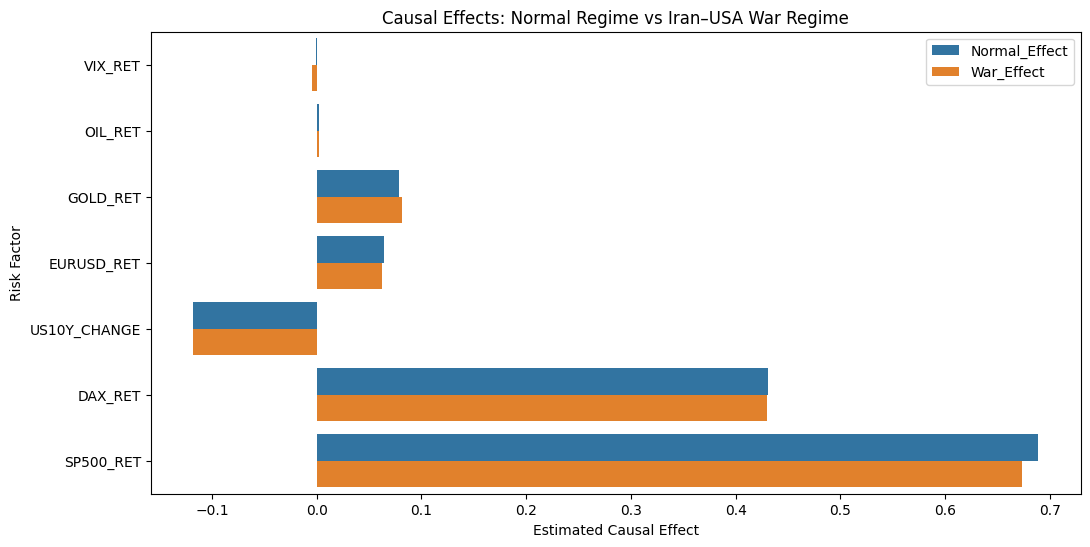

In [110]:
# Visual comparison

regime_plot = regime_comparison.melt(
    id_vars="Factor",
    value_vars=["Normal_Effect", "War_Effect"],
    var_name="Regime",
    value_name="Causal_Effect"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=regime_plot,
    x="Causal_Effect",
    y="Factor",
    hue="Regime"
)

plt.title("Causal Effects: Normal Regime vs Iran–USA War Regime")
plt.xlabel("Estimated Causal Effect")
plt.ylabel("Risk Factor")
plt.legend()
plt.show()

#18.1 Interpretation Template

The causal attribution results show that portfolio risk is not driven equally by all risk factors.

During the normal regime, portfolio returns are mainly explained by traditional market factors such as equity returns, interest-rate exposure, and volatility.

During the Iran–USA war stress regime, the causal structure changes. Geopolitical-sensitive factors such as oil, gold, VIX, and exchange rates may become more important.

A larger absolute causal effect during the war period suggests that the portfolio becomes more sensitive to that factor under geopolitical stress.

This confirms that causal risk attribution provides richer insight than correlation-based attribution because it estimates the impact of hypothetical interventions rather than only historical co-movement.